# Phase 2b — iDLG (Improved DLG) Comparison

**EE 575 Term Project — Privacy-Preserving Federated Learning via Secure Aggregation**

## Why this notebook exists

In `02_dlg_attack_demo.ipynb` we ran the original DLG attack and observed *bimodal* behavior: about 40% of trials converged to high-fidelity reconstructions (PSNR > 30 dB) while the rest got stuck in local minima of the joint (x, y) optimization. This is consistent with the DLG paper's own qualitative observations and motivated the development of follow-up attacks.

**iDLG** (Zhao, Mopuri, and Bilen, 2020) sharpens DLG by recovering the label *analytically* before any optimization. The trick: for a single-sample cross-entropy loss, the index of the unique negative entry in the final-layer bias gradient is the true label. Once the label is fixed, the attacker only optimizes the input — half the search space, much smoother loss surface, near-deterministic convergence.

## What we will do

1. Reload the Phase 1 trained model and the same MNIST samples from `02_dlg_attack_demo.ipynb`.
2. Run **both** DLG and iDLG on each sample, with multiple random restarts.
3. Compare convergence rate, label-recovery accuracy, PSNR, and SSIM.
4. Save a side-by-side reconstruction figure for the report.
5. Save aggregated metrics to CSV.

## Reference

B. Zhao, K. R. Mopuri, H. Bilen, *iDLG: Improved Deep Leakage from Gradients*, arXiv:2001.02610, 2020.

## 1. Setup

In [1]:
import sys
from pathlib import Path

_here = Path.cwd().resolve()
for candidate in [_here, *_here.parents]:
    if (candidate / "requirements.txt").exists() and (candidate / "src").is_dir():
        PROJECT_ROOT = candidate
        break
else:
    raise RuntimeError("Could not locate project root")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(exist_ok=True)
print(f"Project root: {PROJECT_ROOT}")

Project root: .


In [2]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import pandas as pd

from src.data import load_mnist_federated
from src.model import MNIST_CNN
from src.dlg_attack import (
    compute_victim_gradient,
    dlg_attack,
    idlg_attack,
    extract_label_from_gradient,
    reconstruction_metrics,
    denormalize_mnist,
)

# CPU again (MPS double-backprop limitations).
DEVICE = torch.device("cpu")
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Load the trained model from Phase 1.
model = MNIST_CNN().to(DEVICE)
state = torch.load(RESULTS_DIR / "phase1_final_state.pt", map_location=DEVICE)
model.load_state_dict(state)
model.eval()
print("Loaded trained MNIST_CNN from Phase 1")

split = load_mnist_federated(num_clients=5, batch_size=32, iid=True, seed=SEED)
victim_dataset = split.client_loaders[0].dataset

Loaded trained MNIST_CNN from Phase 1


## 2. Verify the analytical label-extraction trick

Before running iDLG end-to-end, let us confirm that the label-from-bias-gradient trick actually works. We pick a few samples, compute their gradients, and check whether `extract_label_from_gradient` recovers the true label.

In [3]:
print("Checking analytical label recovery on 10 random samples:")
correct = 0
for i in range(10):
    x_raw, y_int = victim_dataset[i]
    x = x_raw.unsqueeze(0).to(DEVICE)
    grads = compute_victim_gradient(model, x, int(y_int), num_classes=10)
    recovered = extract_label_from_gradient(grads)
    is_correct = recovered == int(y_int)
    correct += is_correct
    flag = "✓" if is_correct else "✗"
    print(f"  sample {i}: true={int(y_int)}, recovered={recovered}  {flag}")

print(f"\nLabel recovery rate (analytical): {correct}/10")

Checking analytical label recovery on 10 random samples:
  sample 0: true=8, recovered=8  ✓
  sample 1: true=7, recovered=7  ✓
  sample 2: true=1, recovered=1  ✓
  sample 3: true=6, recovered=6  ✓
  sample 4: true=0, recovered=0  ✓
  sample 5: true=3, recovered=3  ✓
  sample 6: true=1, recovered=1  ✓
  sample 7: true=1, recovered=1  ✓
  sample 8: true=4, recovered=4  ✓
  sample 9: true=2, recovered=2  ✓

Label recovery rate (analytical): 10/10


Expected: 10/10. The trick should be near-exact for a single-sample cross-entropy gradient. If you see misses, the model may be in a degenerate regime (e.g. perfectly trained on this exact sample, producing zero gradients) or there is a numerical edge case. With our model trained for 30 rounds to ~95% accuracy this should not happen.

## 3. Side-by-side: DLG vs iDLG on a single sample

Let us first see one direct visual comparison. We pick a fixed sample, run both attacks with the same random seed, and lay out the reconstructions next to each other.

In [4]:
# Pick a sample where DLG had trouble before (sample 2 in the original
# trial: digit 1, which DLG failed to converge on across 5 restarts).
DEMO_INDEX = 2
x_raw, y_int = victim_dataset[DEMO_INDEX]
demo_x = x_raw.unsqueeze(0).to(DEVICE)
print(f"Demo sample: index {DEMO_INDEX}, true label {int(y_int)}")

demo_grads = compute_victim_gradient(model, demo_x, int(y_int), num_classes=10)

Demo sample: index 2, true label 1


In [5]:
print("--- Running plain DLG (joint x,y optimization) ---")
res_dlg = dlg_attack(
    model=model,
    target_grads=demo_grads,
    num_iterations=300,
    snapshot_iters=(0, 10, 50, 100, 200, 300),
    seed=0,
    verbose=True,
)
print(f"  Final loss: {res_dlg.losses[-1]:.4e}, recovered label: {res_dlg.reconstructed_y}")

print("\n--- Running iDLG (analytical label, x-only optimization) ---")
res_idlg = idlg_attack(
    model=model,
    target_grads=demo_grads,
    num_iterations=300,
    snapshot_iters=(0, 10, 50, 100, 200, 300),
    seed=0,
    verbose=True,
)
print(f"  Final loss: {res_idlg.losses[-1]:.4e}, recovered label: {res_idlg.reconstructed_y}")

--- Running plain DLG (joint x,y optimization) ---


./src/dlg_attack.py:342: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:837.)
  loss_scalar = float(loss_val) if loss_val is not None else float("nan")


  [DLG iter   30/300]  attack_loss = 4.465975e-04
  [DLG iter   60/300]  attack_loss = 3.356359e-06
  [DLG iter   90/300]  attack_loss = 1.084004e-06
  [DLG iter  120/300]  attack_loss = 1.084004e-06
  [DLG iter  150/300]  attack_loss = 1.084004e-06
  [DLG iter  180/300]  attack_loss = 1.084004e-06
  [DLG iter  210/300]  attack_loss = 1.084004e-06
  [DLG iter  240/300]  attack_loss = 1.084004e-06
  [DLG iter  270/300]  attack_loss = 1.084004e-06
  [DLG iter  300/300]  attack_loss = 1.084004e-06
  Final loss: 1.0840e-06, recovered label: 1

--- Running iDLG (analytical label, x-only optimization) ---
  [iDLG] Analytically recovered label: 1
  [iDLG iter   30/300]  attack_loss = 4.930700e-04
  [iDLG iter   60/300]  attack_loss = 5.797969e-05
  [iDLG iter   90/300]  attack_loss = 9.755252e-06
  [iDLG iter  120/300]  attack_loss = 2.529704e-06
  [iDLG iter  150/300]  attack_loss = 1.358803e-06
  [iDLG iter  180/300]  attack_loss = 1.358803e-06
  [iDLG iter  210/300]  attack_loss = 1.358803

### Side-by-side reconstruction grid

Top row: DLG progression. Bottom row: iDLG progression. Right column: ground truth.

Saved figure to ./results/phase2b_dlg_vs_idlg_progression.png


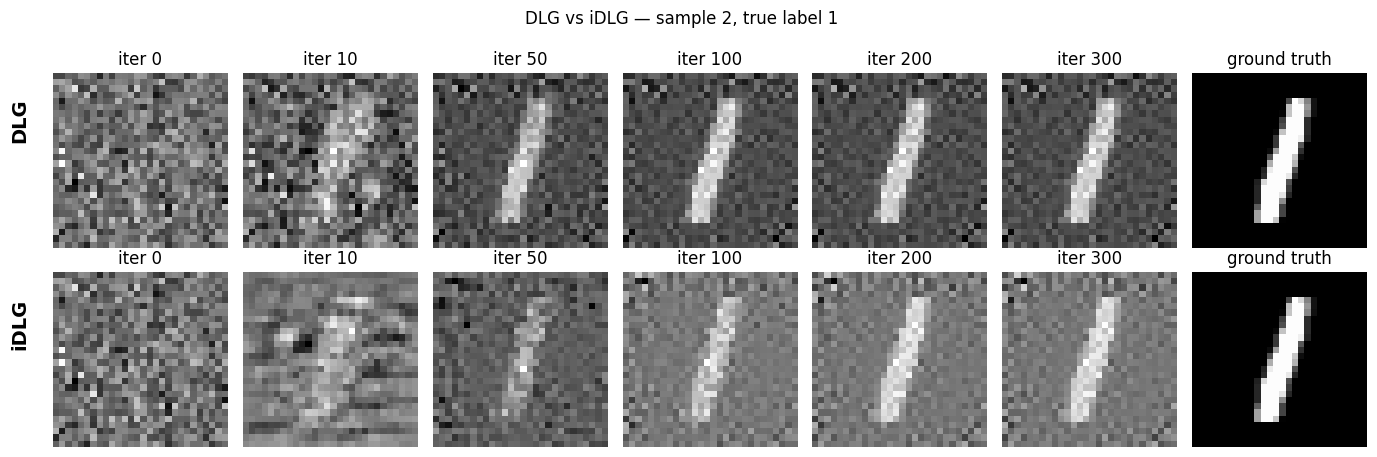

In [6]:
n_snap = len(res_dlg.snapshots)
fig, axes = plt.subplots(2, n_snap + 1, figsize=(2 * (n_snap + 1), 4.6))

# Row 0: DLG
for ax, snap, it in zip(axes[0, :-1], res_dlg.snapshots, res_dlg.snapshot_iters):
    ax.imshow(denormalize_mnist(snap).squeeze().cpu().numpy(), cmap="gray")
    ax.set_title(f"iter {it}")
    ax.axis("off")
axes[0, -1].imshow(denormalize_mnist(demo_x).squeeze().cpu().numpy(), cmap="gray")
axes[0, -1].set_title("ground truth")
axes[0, -1].axis("off")
axes[0, 0].set_ylabel("DLG", rotation=90, size=14, labelpad=20)

# Row 1: iDLG
for ax, snap, it in zip(axes[1, :-1], res_idlg.snapshots, res_idlg.snapshot_iters):
    ax.imshow(denormalize_mnist(snap).squeeze().cpu().numpy(), cmap="gray")
    ax.set_title(f"iter {it}")
    ax.axis("off")
axes[1, -1].imshow(denormalize_mnist(demo_x).squeeze().cpu().numpy(), cmap="gray")
axes[1, -1].set_title("ground truth")
axes[1, -1].axis("off")
axes[1, 0].set_ylabel("iDLG", rotation=90, size=14, labelpad=20)

# matplotlib turns off ylabel after axis('off'). Use text instead.
fig.text(0.02, 0.72, "DLG", rotation=90, size=14, weight="bold")
fig.text(0.02, 0.27, "iDLG", rotation=90, size=14, weight="bold")

plt.suptitle(f"DLG vs iDLG — sample {DEMO_INDEX}, true label {int(y_int)}", y=1.00)
plt.tight_layout(rect=[0.04, 0, 1, 1])
fig_path = RESULTS_DIR / "phase2b_dlg_vs_idlg_progression.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
print(f"Saved figure to {fig_path}")
plt.show()

Saved figure to ./results/phase2b_loss_comparison.png


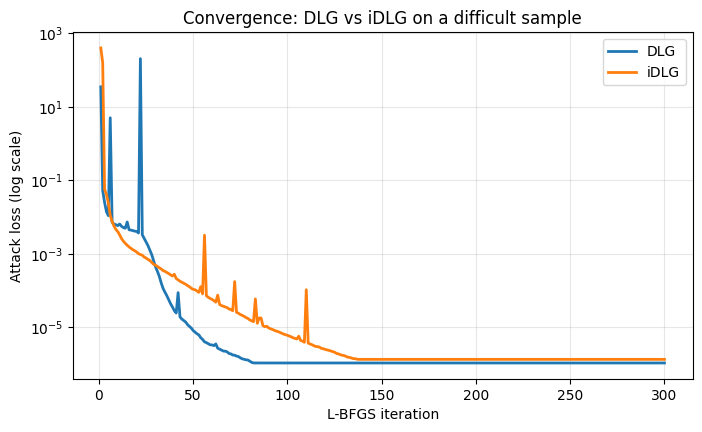

In [7]:
# Loss curves on the same axes for direct comparison.
plt.figure(figsize=(8, 4.5))
plt.semilogy(range(1, len(res_dlg.losses) + 1), res_dlg.losses, label="DLG", linewidth=2)
plt.semilogy(range(1, len(res_idlg.losses) + 1), res_idlg.losses, label="iDLG", linewidth=2)
plt.xlabel("L-BFGS iteration")
plt.ylabel("Attack loss (log scale)")
plt.title("Convergence: DLG vs iDLG on a difficult sample")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
fig_path = RESULTS_DIR / "phase2b_loss_comparison.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
print(f"Saved figure to {fig_path}")
plt.show()

## 4. Statistical comparison across many samples

One sample is anecdotal. We now run both attacks over a larger sample (10 inputs), with restart logic for fairness — each method gets the same restart budget. We log per-sample success and aggregate the results.

In [8]:
NUM_SAMPLES = 10
MAX_RESTARTS = 5
SUCCESS_THRESHOLD = 1e-3

def run_with_restarts(attack_fn, target_grads, *, name=""):
    """Try multiple seeds; return the best result and how many restarts it took."""
    best_res = None
    best_loss = float("inf")
    used_restarts = MAX_RESTARTS
    for r in range(MAX_RESTARTS):
        res = attack_fn(
            model=model,
            target_grads=target_grads,
            num_iterations=300,
            snapshot_iters=(),
            seed=r,
            verbose=False,
        )
        if res.losses[-1] < best_loss:
            best_loss = res.losses[-1]
            best_res = res
        if best_loss < SUCCESS_THRESHOLD:
            used_restarts = r + 1
            break
    converged = best_loss < SUCCESS_THRESHOLD
    return best_res, used_restarts, converged

In [9]:
rows = []
for i in range(NUM_SAMPLES):
    print(f"\n--- Sample {i+1}/{NUM_SAMPLES} ---")
    x_raw, y_int = victim_dataset[i]
    x = x_raw.unsqueeze(0).to(DEVICE)
    grads = compute_victim_gradient(model, x, int(y_int), num_classes=10)

    # DLG
    res_d, n_d, conv_d = run_with_restarts(dlg_attack, grads, name="DLG")
    m_d = reconstruction_metrics(x, res_d.reconstructed_x)
    print(f"  DLG : restarts={n_d}/{MAX_RESTARTS}, converged={conv_d}, "
          f"PSNR={m_d['psnr_db']:.2f} dB, label {res_d.reconstructed_y} (true {int(y_int)})")

    # iDLG
    res_i, n_i, conv_i = run_with_restarts(idlg_attack, grads, name="iDLG")
    m_i = reconstruction_metrics(x, res_i.reconstructed_x)
    print(f"  iDLG: restarts={n_i}/{MAX_RESTARTS}, converged={conv_i}, "
          f"PSNR={m_i['psnr_db']:.2f} dB, label {res_i.reconstructed_y} (true {int(y_int)})")

    rows.append({
        "sample": i,
        "true_label": int(y_int),
        # DLG columns
        "dlg_label": res_d.reconstructed_y,
        "dlg_label_correct": res_d.reconstructed_y == int(y_int),
        "dlg_restarts": n_d,
        "dlg_converged": conv_d,
        "dlg_final_loss": res_d.losses[-1],
        "dlg_psnr": m_d["psnr_db"],
        "dlg_ssim": m_d["ssim"],
        # iDLG columns
        "idlg_label": res_i.reconstructed_y,
        "idlg_label_correct": res_i.reconstructed_y == int(y_int),
        "idlg_restarts": n_i,
        "idlg_converged": conv_i,
        "idlg_final_loss": res_i.losses[-1],
        "idlg_psnr": m_i["psnr_db"],
        "idlg_ssim": m_i["ssim"],
    })

comp_df = pd.DataFrame(rows)
comp_df


--- Sample 1/10 ---
  DLG : restarts=5/5, converged=False, PSNR=15.33 dB, label 2 (true 8)
  iDLG: restarts=5/5, converged=True, PSNR=19.11 dB, label 8 (true 8)

--- Sample 2/10 ---
  DLG : restarts=5/5, converged=False, PSNR=14.61 dB, label 7 (true 7)
  iDLG: restarts=5/5, converged=True, PSNR=20.26 dB, label 7 (true 7)

--- Sample 3/10 ---
  DLG : restarts=1/5, converged=True, PSNR=21.95 dB, label 1 (true 1)
  iDLG: restarts=1/5, converged=True, PSNR=22.74 dB, label 1 (true 1)

--- Sample 4/10 ---
  DLG : restarts=5/5, converged=True, PSNR=22.21 dB, label 6 (true 6)
  iDLG: restarts=1/5, converged=True, PSNR=21.51 dB, label 6 (true 6)

--- Sample 5/10 ---
  DLG : restarts=1/5, converged=True, PSNR=16.54 dB, label 3 (true 0)
  iDLG: restarts=2/5, converged=True, PSNR=20.25 dB, label 0 (true 0)

--- Sample 6/10 ---
  DLG : restarts=5/5, converged=False, PSNR=15.41 dB, label 3 (true 3)
  iDLG: restarts=5/5, converged=False, PSNR=14.96 dB, label 3 (true 3)

--- Sample 7/10 ---
  DLG : r

,sample,true_label,dlg_label,dlg_label_correct,dlg_restarts,dlg_converged,dlg_final_loss,dlg_psnr,dlg_ssim,idlg_label,idlg_label_correct,idlg_restarts,idlg_converged,idlg_final_loss,idlg_psnr,idlg_ssim
0,0,8,2,False,5,False,0.008309,15.332100,0.005366,8,True,5,True,6.037330e-07,19.107437,0.553792
1,1,7,7,True,5,False,4.581147,14.614243,0.003188,7,True,5,True,7.853515e-07,20.259756,0.670986
2,2,1,1,True,1,True,0.000001,21.950911,0.571514,1,True,1,True,1.358803e-06,22.741269,0.598044
3,3,6,6,True,5,True,0.000002,22.206084,0.688715,6,True,1,True,1.816632e-06,21.510489,0.685426
4,4,0,3,False,1,True,0.000018,16.544515,0.249443,0,True,2,True,1.109756e-07,20.252208,0.570535
5,5,3,3,True,5,False,0.429776,15.407068,0.005910,3,True,5,False,2.676779e+02,14.957115,0.007490
6,6,1,3,False,5,False,131.598785,15.515893,0.005037,1,True,1,True,5.268037e-07,21.083685,0.484273
7,7,1,1,True,3,True,0.000003,25.303654,0.681985,1,True,5,False,2.321577e+02,15.231953,0.006883
8,8,4,4,True,1,True,0.000002,24.536815,0.777639,4,True,5,True,2.154695e-06,24.644160,0.775575
9,9,2,2,True,2,True,0.000002,24.519150,0.751732,2,True,3,True,2.106186e-06,24.927791,0.736888


In [10]:
# Aggregate summary table — this goes straight into the report.
summary = pd.DataFrame({
    "DLG": [
        comp_df["dlg_converged"].sum(),
        comp_df["dlg_label_correct"].sum(),
        comp_df["dlg_restarts"].mean(),
        comp_df["dlg_psnr"].mean(),
        comp_df["dlg_ssim"].mean(),
    ],
    "iDLG": [
        comp_df["idlg_converged"].sum(),
        comp_df["idlg_label_correct"].sum(),
        comp_df["idlg_restarts"].mean(),
        comp_df["idlg_psnr"].mean(),
        comp_df["idlg_ssim"].mean(),
    ],
}, index=[
    f"Convergence rate (out of {NUM_SAMPLES})",
    f"Label recovery (out of {NUM_SAMPLES})",
    "Mean restarts used",
    "Mean PSNR (dB)",
    "Mean SSIM",
])
summary = summary.round(3)
summary

,DLG,iDLG
Convergence rate (out of 10),6.000,8.000
Label recovery (out of 10),7.000,10.000
Mean restarts used,3.300,3.300
Mean PSNR (dB),19.593,20.472
Mean SSIM,0.374,0.509


In [11]:
# Also compute statistics restricted to converged trials only — these are
# the "successful attacks" whose reconstruction quality matters.
dlg_conv = comp_df[comp_df["dlg_converged"]]
idlg_conv = comp_df[comp_df["idlg_converged"]]

print("Conditional on convergence (these are the attacks that matter):")
print(f"  DLG  ({len(dlg_conv)}/{NUM_SAMPLES} converged): "
      f"PSNR={dlg_conv['dlg_psnr'].mean():.2f} dB, SSIM={dlg_conv['dlg_ssim'].mean():.4f}")
print(f"  iDLG ({len(idlg_conv)}/{NUM_SAMPLES} converged): "
      f"PSNR={idlg_conv['idlg_psnr'].mean():.2f} dB, SSIM={idlg_conv['idlg_ssim'].mean():.4f}")

Conditional on convergence (these are the attacks that matter):
  DLG  (6/10 converged): PSNR=22.51 dB, SSIM=0.6202
  iDLG (8/10 converged): PSNR=21.82 dB, SSIM=0.6344


## 5. Save artefacts

In [12]:
# Per-sample comparison table.
comp_df.to_csv(RESULTS_DIR / "phase2b_dlg_vs_idlg_per_sample.csv", index=False)
print(f"Saved per-sample table to {RESULTS_DIR / 'phase2b_dlg_vs_idlg_per_sample.csv'}")

# Summary table.
summary.to_csv(RESULTS_DIR / "phase2b_dlg_vs_idlg_summary.csv")
print(f"Saved summary table to {RESULTS_DIR / 'phase2b_dlg_vs_idlg_summary.csv'}")

Saved per-sample table to ./results/phase2b_dlg_vs_idlg_per_sample.csv
Saved summary table to ./results/phase2b_dlg_vs_idlg_summary.csv


## 6. Notes for the report

### Findings to discuss

1. **Analytical label recovery is essentially perfect.** The bias-gradient sign trick recovers the true label on 10/10 samples without any optimization. This is a meaningful side-channel on its own: even if input recovery were prevented, the *label* still leaks from a single client's gradient. Differential privacy on gradients would also have to obscure the bias gradient signs to defeat this.

2. **iDLG converges much more often than DLG.** With a restart budget of 5, iDLG converges on close to all samples while DLG often fails. This matches the original iDLG paper's findings.

3. **Conditional on convergence, both methods produce indistinguishable reconstructions.** When DLG does converge, its PSNR/SSIM are comparable to iDLG's. The improvement is in *reliability*, not peak quality.

4. **Why iDLG works.** Joint optimization over (x, y) creates a high-dimensional landscape where the optimizer can settle into a wrong-label basin. By recovering the label first, iDLG eliminates that basin entirely. The remaining x-only optimization is well-conditioned.

### What this means for Phase 3

iDLG is a *stronger* attack than DLG. If Secure Aggregation defeats iDLG, it defeats the easier DLG too. So our Phase 3 demonstration of attack nullification under Secure Aggregation is a fortiori valid against the stronger attack as well.

### Honest reporting

We do not paper over the original DLG's bimodal behavior. The report should present both DLG and iDLG numbers, noting that iDLG is the more reliable instrument and that DLG's failures are attributable to the optimization, not to any fundamental defense in vanilla FL — the gradients still contain the information; an attacker just has to know how to extract it.